# "Regression and Other Stories", Chapter 11 Exercises

In [60]:
import arviz
import bambi
import numpy
import pandas

from matplotlib import pyplot
from scipy import stats

In [61]:
_BASE_SEED = """Chapter 11 -- that's the bankruptcy one.  All I can think of.  
    Even when we're on Chapter 13 I won't be thinking bankruptcy the way i am
    right now, here in Chapter 11"""

def fresh_prng(seed: str):
    return numpy.random.default_rng(seed=abs(hash(_BASE_SEED + seed)) % (2 ** 32))

## 11.3, Coverage of confidence intervals

> Consider the following procedure:
>
> *  Set $n = 100$ and draw $n$ continuous values $x_i$ uniformly distributed
>    between 0 and 10. Then simulate data from the model
>    $y_i = a + bx_i + \text{error}_i$, for $i = 1, \ldots, n$, with $a = 2$,
>    $b = 3$, and independent errors from a normal distribution.
>    
> *  Regress $y$ on $x$. Look at the median and mad sd of $b$. Check to see if
>    the interval formed by the median $\pm 2$ mad sd includes the true value,
>    $b = 3$.
>
> *  Repeat the above two steps 1000 times.
>
> (a) True or false: the interval should contain the true value approximately
>     950 times. Explain your answer.
>
> (b) Same as above, except the error distribution is bimodal, not normal. True
>     or false: the interval should contain the true value approximately 950
>     times. Explain your answer.

In [62]:
rng = fresh_prng("Exercise 11.3, Coverage of confidence intervals")

In [63]:
def regression_11_3(bimodal_noise: bool) -> bool:
    n = 100
    xs = rng.uniform(low=0, high=10, size=n)
    if bimodal_noise:
        zs = rng.choice([-1, 1], size=n)
        noise = rng.normal(loc=zs)
    else:
        noise = rng.normal(scale=1.4, size=n)
    ys = 2 + 3 * xs + noise
    model = stats.linregress(xs, ys)
    return abs(model.slope - 3) < (2 * model.stderr)

normal_count = 0
bimode_count = 0
for _ in range(1000):
    if regression_11_3(False):
        normal_count += 1
    if regression_11_3(True):
        bimode_count += 1
print(f'Normal noise: {normal_count} / 1000')
print(f'Bimodal noise: {bimode_count} / 1000')

Normal noise: 943 / 1000
Bimodal noise: 958 / 1000


## 11.4, Interpreting residual plots

> Anna takes continuous data $x_1$ and binary data $x_2$, creates fake data
> $y$ from the model, $y = a + b_1x_1 + b_2x_2 + b_3x_1x_2 + \text{error}$, and
> gives these data to Barb, who, not knowing how the data were constructed, fits
> a linear regression predicting $y$ from $x_1$ and $x_2$ but without the
> interaction. In these data, Barb makes a residual plot of $y$ vs. $x_1$, using
> dots and circles to display points with $x_2 = 0$ and $x_2 = 1$, respectively.
> The residual plot indicates to Barb that she should fit the interaction model.
> Sketch with pen on paper a residual plot that Barb could have seen after
> fitting the regression without interaction.

In [64]:
rng = fresh_prng("Exercise 11.4, Interpreting residual plots")

In [65]:
x1s = rng.normal(scale=3, size=40)
x2s = rng.choice(2, size=40)
a = 1
b1 = -2
b2 = 3
b3 = -4
ys = rng.normal(loc=(a + b1 * x1s + b2 * x2s + b3 * x1s * x2s))

In [66]:
ex4_df = pandas.DataFrame(data={'x1': x1s, 'x2': x2s, 'y': ys})

In [68]:
model_linear = bambi.Model('y ~ x1 + x2', ex4_df)
fit_linear = model_linear.fit()
summ_linear = arviz.summary(fit_linear, var_names='~mu')
a_hat = summ_linear['mean']['Intercept']
b1_hat = summ_linear['mean']['x1']
b2_hat = summ_linear['mean']['x2']
arviz.summary(fit_linear, var_names='~mu')

Initializing NUTS using jitter+adapt_diag...
/home/bgawalt/venv/ros/lib/python3.10/site-packages/pytensor/link/c/cmodule.py:2968: UserWarning: PyTensor could not link to a BLAS installation. Operations that might benefit from BLAS will be severely degraded.
This usually happens when PyTensor is installed via pip. We recommend it be installed via conda/mamba/pixi instead.
Alternatively, you can use an experimental backend such as Numba or JAX that perform their own BLAS optimizations, by setting `pytensor.config.mode == 'NUMBA'` or passing `mode='NUMBA'` when compiling a PyTensor function.
For more options and details see https://pytensor.readthedocs.io/en/latest/troubleshooting.html#how-do-i-configure-test-my-blas-library
  warnings.warn(
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, x1, x2]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.
/home/bgawalt/venv/ros/lib/python3.10/site-packages/arviz/utils.py:146: UserWarning: Items starting with ~: ['mu'] have not been found and will be ignored
  warnings.warn(
/home/bgawalt/venv/ros/lib/python3.10/site-packages/arviz/utils.py:146: UserWarning: Items starting with ~: ['mu'] have not been found and will be ignored
  warnings.warn(


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma,5.650,0.698,4.391,6.955,0.010,0.013,4608.0,2180.0,1.0
Intercept,-0.883,1.350,-3.451,1.741,0.019,0.021,4872.0,3370.0,1.0
x1,-4.555,0.316,-5.177,-3.985,0.004,0.005,5086.0,3164.0,1.0
x2,4.784,1.829,1.339,8.213,0.025,0.029,5414.0,3197.0,1.0


In [69]:
rs = ys - (a_hat + b1_hat * x1s + b2_hat * x2s)

Text(0, 0.5, 'Residual')

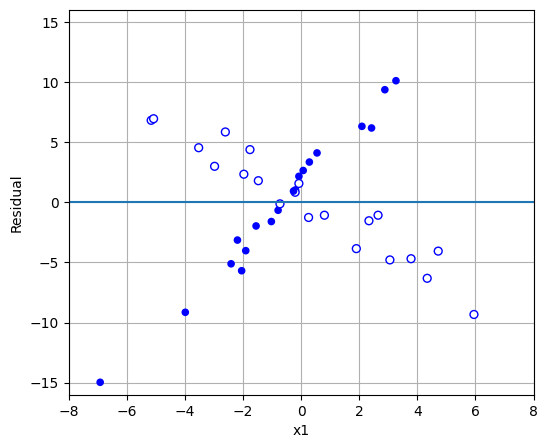

In [75]:
fig = pyplot.figure(figsize=(6, 5))
ax = fig.gca()
ax.scatter(
    x1s,
    rs,
    s=[32 if x2i == 1 else 20 for x2i in x2s],
    c=['w' if x2i == 1 else 'b' for x2i in x2s],
    edgecolors='b',
)
ax.grid()
ax.set_xlim(-8, 8)
ax.set_ylim(-16, 16)
ax.axhline(y=0)
ax.set_axisbelow(True)
ax.set_xlabel("x1")
ax.set_ylabel("Residual")